# ASL Training Notebook

This notebook provides the cells required to train an ASL ML model on Apple silicon.

**Project goal:** train a model on folders `A` to `Z`, then export efficient versions for deployment.

**Important note:** this approach is best for static ASL letters. `J` and `Z` are motion-based signs, so a single-image classifier usually performs worse on them.

Dataset sources: 
- https://www.kaggle.com/datasets/ayuraj/asl-dataset?resource=download
- https://data.mendeley.com/datasets/48dg9vhmyk/2

## 1. Install dependencies

Run this once in your terminal, ideally in a fresh virtual environment on Apple Silicon:

```bash
python3 -m venv asl_env
source asl_env/bin/activate
python -m pip install --upgrade pip
pip install tensorflow tensorflow-metal tensorflow-model-optimization opencv-python mediapipe numpy matplotlib scikit-learn jupyter
```

In [ ]:
# !pip install "numpy<2" tensorflow==2.15.1 tensorflow-metal==1.1.0 tf_keras==2.15.1 tensorflow-model-optimization
# !pip install opencv-python mediapipe matplotlib scikit-learn jupyter ipykernel
# !python -m ipykernel install --user --name asl_train_gpu2 --display-name "Python (asl_train_gpu2)"

In [1]:
# 2. Imports and global configuration
import os
import json
import time
import zipfile
import random
import platform
import tempfile
from pathlib import Path

import numpy as np
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_USE_LEGACY_KERAS'] = '1' 
import tensorflow as tf
print(tf.__file__)
print(tf.config.list_physical_devices())

try:
    import tensorflow_model_optimization as tfmot
except Exception:
    tfmot = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
try:
    tf.random.set_seed(SEED)
except Exception:
    pass

DATA_DIR = Path("Data")   # <-- change this
OUT_DIR = Path("artifacts")
IMAGE_SIZE = 224
BATCH_SIZE = 128
VAL_SPLIT = 0.15
TEST_SPLIT = 0.10
EPOCHS_HEAD = 8
EPOCHS_FINE = 8
EPOCHS_FINETUNE = 6
FINE_TUNE_AT = 80
LR_HEAD = 1e-3
LR_FINETUNE = 1e-5
LR_FINE = 1e-5

ENABLE_PRUNING = True
TARGET_SPARSITY = 0.2
PRUNING_EPOCHS = 5
USE_MIXED_PRECISION = False

OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Artifacts will be saved in:", OUT_DIR.resolve())

/opt/anaconda3/envs/asl_train_gpu2/lib/python3.10/site-packages/tensorflow/__init__.py
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Artifacts will be saved in: /Users/kareemyoussef/Documents/University/UofC/Winter 2026/ENDG511/Project/Codebase/artifacts


In [2]:
# 3. Apple Silicon / runtime setup
from tensorflow.keras import mixed_precision

def configure_runtime(prefer_mixed_precision=True):
    info = {
        "platform": platform.platform(),
        "machine": platform.machine(),
        "tensorflow_version": tf.__version__,
        "is_apple_silicon": platform.system() == "Darwin" and platform.machine() == "arm64",
        "gpus": [d.name for d in tf.config.list_physical_devices("GPU")],
        "using_mixed_precision": False,
    }

    if prefer_mixed_precision and info["gpus"]:
        try:
            mixed_precision.set_global_policy("mixed_float16")
            info["using_mixed_precision"] = True
        except Exception as e:
            info["mixed_precision_error"] = str(e)

    print(json.dumps(info, indent=2))

    with open(OUT_DIR / "runtime_info.json", "w", encoding="utf-8") as f:
        json.dump(info, f, indent=2)

    return info

runtime_info = configure_runtime(prefer_mixed_precision=USE_MIXED_PRECISION)

{
  "platform": "macOS-26.2-arm64-arm-64bit",
  "machine": "arm64",
  "tensorflow_version": "2.15.1",
  "is_apple_silicon": true,
  "gpus": [
    "/physical_device:GPU:0"
  ],
  "using_mixed_precision": false
}


In [ ]:
# 4. Helper functions
CLASS_NAMES_KEY = "class_names"


def infer_class_names(data_dir: Path):
    classes = [p.name for p in sorted(data_dir.iterdir()) if p.is_dir()]
    if not classes:
        raise ValueError(f"No class folders found in {data_dir}")
    return classes


def build_datasets(data_dir, image_size=(224, 224), batch_size=32, val_split=0.15, test_split=0.10):
    classes = infer_class_names(data_dir)

    filepaths = []
    labels = []
    class_to_idx = {cls: i for i, cls in enumerate(classes)}

    data_dir = Path(data_dir)

    for cls in classes:
        class_dir = data_dir / cls
        for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
            for fp in class_dir.glob(ext):
                filepaths.append(str(fp))
                labels.append(class_to_idx[cls])

    filepaths = np.array(filepaths)
    labels = np.array(labels)

    rng = np.random.default_rng(SEED)
    indices = np.arange(len(filepaths))
    rng.shuffle(indices)

    filepaths = filepaths[indices]
    labels = labels[indices]

    n_total = len(filepaths)
    n_test = int(n_total * test_split)
    n_val = int(n_total * val_split)
    n_train = n_total - n_val - n_test

    train_paths = filepaths[:n_train]
    train_labels = labels[:n_train]

    val_paths = filepaths[n_train:n_train + n_val]
    val_labels = labels[n_train:n_train + n_val]

    test_paths = filepaths[n_train + n_val:]
    test_labels = labels[n_train + n_val:]

    def load_and_preprocess(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, image_size)
        img = tf.cast(img, tf.float32)
        return img, label

    autotune = tf.data.AUTOTUNE

    train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=autotune)
    train_ds = train_ds.cache().shuffle(1000, seed=SEED).batch(batch_size).prefetch(autotune)

    val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=autotune)
    val_ds = val_ds.cache().batch(batch_size).prefetch(autotune)

    test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
    test_ds = test_ds.map(load_and_preprocess, num_parallel_calls=autotune)
    test_ds = test_ds.batch(batch_size).prefetch(autotune)

    print(f"Train samples: {len(train_paths)}")
    print(f"Val samples:   {len(val_paths)}")
    print(f"Test samples:  {len(test_paths)}")

    return train_ds, val_ds, test_ds, classes


def save_metadata(out_dir: Path, class_names, image_size):
    meta = {
        CLASS_NAMES_KEY: class_names,
        "image_size": list(image_size),
        "num_classes": len(class_names),
        "notes": "Static ASL alphabet classifier. J and Z may be weak because they are dynamic gestures.",
    }
    with open(out_dir / "metadata.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)


def build_model(num_classes: int, input_shape=(224, 224, 3), dropout_rate: float = 0.30):
    data_augmentation = tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.15),       # was 0.08
            tf.keras.layers.RandomZoom(0.20),            # was 0.10
            tf.keras.layers.RandomContrast(0.20),        # was 0.10
            tf.keras.layers.RandomTranslation(0.15, 0.15),  # was 0.08
            tf.keras.layers.RandomBrightness(0.2),       # new — simulates lighting variation
        ],
        name="augmentation",
    )

    backbone = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
        alpha=0.75,
    )
    backbone.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = backbone(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", dtype="float32", name="predictions")(x)
    return tf.keras.Model(inputs, outputs, name="asl_mobilenetv2")


def compile_model(model, lr=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=lr),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )


def unfreeze_backbone(model, fine_tune_at=80):
    backbone = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and "mobilenetv2" in layer.name.lower():
            backbone = layer
            break
    if backbone is None:
        raise ValueError("Could not find MobileNetV2 backbone.")

    backbone.trainable = True
    for layer in backbone.layers[:fine_tune_at]:
        layer.trainable = False


def get_file_size_bytes(path: Path):
    return path.stat().st_size


def get_gzipped_model_size(path: Path):
    _, zipped_file = tempfile.mkstemp(suffix=".zip")
    with zipfile.ZipFile(zipped_file, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        zf.write(path, arcname=path.name)
    return os.path.getsize(zipped_file)


def benchmark_keras_model(model, sample_batch, runs=50):
    _ = model(sample_batch, training=False)
    start = time.time()
    for _ in range(runs):
        _ = model(sample_batch, training=False)
    return (time.time() - start) / runs


def evaluate_model(model, dataset, save_path=None, sample_batch=None):
    loss, acc = model.evaluate(dataset, verbose=0)
    results = {"loss": float(loss), "accuracy": float(acc)}
    if save_path and Path(save_path).exists():
        results["file_size_bytes"] = get_file_size_bytes(Path(save_path))
        results["gzipped_size_bytes"] = get_gzipped_model_size(Path(save_path))
    if sample_batch is not None:
        results["avg_inference_time_seconds"] = benchmark_keras_model(model, sample_batch)
    return results


def collect_representative_data(dataset, num_batches=50):
    for i, (images, _) in enumerate(dataset.take(num_batches)):
        for img in images:
            yield [tf.cast(tf.expand_dims(img, axis=0), tf.float32)]
        if i >= num_batches - 1:
            break


def convert_to_tflite(keras_model, out_path, train_ds=None, quant_mode="none"):
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

    if quant_mode == "fp16":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]
    elif quant_mode == "int8":
        if train_ds is None:
            raise ValueError("train_ds is required for int8 quantization.")
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = lambda: collect_representative_data(train_ds)
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.uint8
        converter.inference_output_type = tf.uint8
    elif quant_mode != "none":
        raise ValueError(f"Unsupported quantization mode: {quant_mode}")

    tflite_model = converter.convert()
    out_path.write_bytes(tflite_model)
    return out_path


def benchmark_tflite_model(tflite_path: Path, sample_batch: np.ndarray, runs=50):
    interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
    interpreter.allocate_tensors()
    in_info = interpreter.get_input_details()[0]
    out_info = interpreter.get_output_details()[0]

    input_index = in_info["index"]
    output_index = out_info["index"]
    input_dtype = in_info["dtype"]
    scale, zero_point = in_info.get("quantization", (0.0, 0))

    x = sample_batch[:1]
    if input_dtype == np.float32:
        x_in = x.astype(np.float32)
    else:
        if scale == 0:
            raise ValueError("Quantized TFLite model has invalid input scale.")
        x_q = np.round(x / scale + zero_point)
        if input_dtype == np.uint8:
            x_in = np.clip(x_q, 0, 255).astype(np.uint8)
        else:
            x_in = np.clip(x_q, -128, 127).astype(np.int8)

    interpreter.set_tensor(input_index, x_in)
    interpreter.invoke()
    _ = interpreter.get_tensor(output_index)

    start = time.time()
    for _ in range(runs):
        interpreter.set_tensor(input_index, x_in)
        interpreter.invoke()
        _ = interpreter.get_tensor(output_index)
    return (time.time() - start) / runs


def apply_pruning(base_model, train_ds, val_ds, target_sparsity=0.2, epochs=5):
    import tensorflow_model_optimization as tfmot

    prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

    end_step = int(tf.data.experimental.cardinality(train_ds).numpy() * epochs)
    pruning_params = {
        "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
            initial_sparsity=0.0,
            final_sparsity=target_sparsity,
            begin_step=0,
            end_step=end_step,
        )
    }

    # Find the backbone and classifier layer from the trained model
    backbone = None
    classifier = None
    dropout_rate = 0.3

    for layer in base_model.layers:
        if isinstance(layer, tf.keras.Model) and "mobilenetv2" in layer.name.lower():
            backbone = layer
        elif isinstance(layer, tf.keras.layers.Dropout):
            dropout_rate = layer.rate
        elif isinstance(layer, tf.keras.layers.Dense) and layer.name == "predictions":
            classifier = layer

    if backbone is None:
        raise ValueError("Could not find MobileNetV2 backbone in base_model.")
    if classifier is None:
        raise ValueError("Could not find final Dense classifier layer in base_model.")

    backbone.trainable = False

    # Rebuild a pruning-safe model that preserves preprocessing
    inputs = tf.keras.Input(shape=base_model.input_shape[1:])
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = backbone(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name="prune_gap")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="prune_dropout")(x)

    pruned_dense = prune_low_magnitude(
        tf.keras.layers.Dense(
            classifier.units,
            activation="softmax",
            dtype="float32",
            name="predictions",
        ),
        **pruning_params
    )
    outputs = pruned_dense(x)

    pruned_model = tf.keras.Model(inputs, outputs, name="pruned_model")

    # Initialize classifier weights from the trained model
    wrapped_output_name = pruned_dense.name
    pruned_model.get_layer(wrapped_output_name).layer.set_weights(classifier.get_weights())

    compile_model(pruned_model, lr=1e-5)

    callbacks = [
        tfmot.sparsity.keras.UpdatePruningStep(),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=2,
            restore_best_weights=True,
            verbose=1,
        ),
    ]

    pruned_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1,
    )

    pruned_model = tfmot.sparsity.keras.strip_pruning(pruned_model)
    compile_model(pruned_model, lr=1e-5)

    return pruned_model

In [4]:
# 5. Build datasets
train_ds, val_ds, test_ds, class_names = build_datasets(
    data_dir=DATA_DIR,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT,
    test_split=TEST_SPLIT,
)

save_metadata(OUT_DIR, class_names, (IMAGE_SIZE, IMAGE_SIZE))
print("Classes:", class_names)

Train samples: 3905
Val samples:   780
Test samples:  520
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


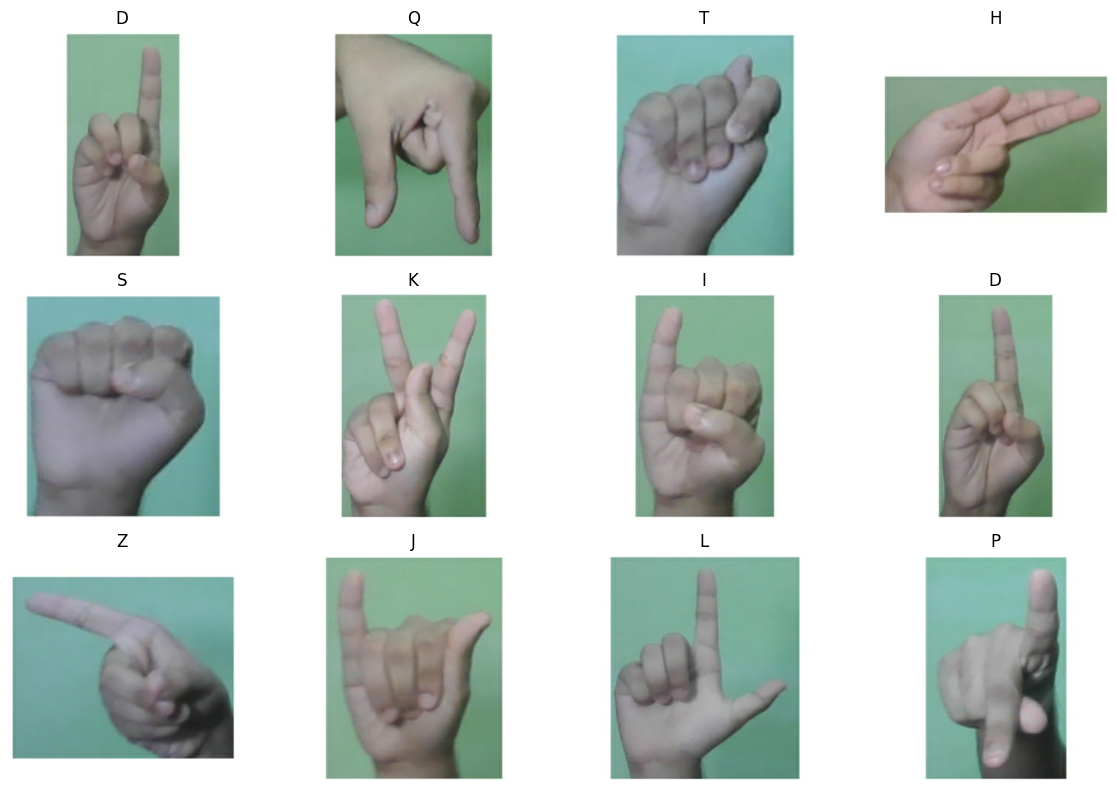

In [5]:
# 6. Inspect one batch
import matplotlib.pyplot as plt

images, labels = next(iter(train_ds.take(1)))
plt.figure(figsize=(12, 8))
for i in range(min(12, len(images))):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[int(labels[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
# 7. Build model
model = build_model(num_classes=len(class_names), input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
compile_model(model, lr=LR_HEAD)
model.summary()

Model: "asl_mobilenetv2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 augmentation (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 tf.math.truediv (TFOpLambd  (None, 224, 224, 3)       0         
 a)                                                              
                                                                 
 tf.math.subtract (TFOpLamb  (None, 224, 224, 3)       0         
 da)                                                             
                                                                 
 mobilenetv2_0.75_224 (Func  (None, 7, 7, 1280)        1382064   
 tional)                                                         
                                                   

In [7]:
# 8. Train classification head

head_checkpoint = OUT_DIR / "best_head.weights.h5"

callbacks_head = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(head_checkpoint),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        verbose=1,
    ),
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks_head,
    verbose=1,
)

# Save a full model AFTER training is done
model.save(OUT_DIR / "after_head_training.keras")
print("Saved head-stage full model.")

Epoch 1/8
31/31 [==============================] - ETA: 0s - loss: 2.6724 - accuracy: 0.2469 
Epoch 1: val_loss improved from inf to 1.76013, saving model to artifacts/best_head.weights.h5
31/31 [==============================] - 487s 16s/step - loss: 2.6724 - accuracy: 0.2469 - val_loss: 1.7601 - val_accuracy: 0.5846 - lr: 0.0010
Epoch 2/8
31/31 [==============================] - ETA: 0s - loss: 1.3749 - accuracy: 0.6440
Epoch 2: val_loss improved from 1.76013 to 1.04750, saving model to artifacts/best_head.weights.h5
31/31 [==============================] - 18s 573ms/step - loss: 1.3749 - accuracy: 0.6440 - val_loss: 1.0475 - val_accuracy: 0.8423 - lr: 0.0010
Epoch 3/8
31/31 [==============================] - ETA: 0s - loss: 0.8844 - accuracy: 0.7982
Epoch 3: val_loss improved from 1.04750 to 0.74451, saving model to artifacts/best_head.weights.h5
31/31 [==============================] - 17s 540ms/step - loss: 0.8844 - accuracy: 0.7982 - val_loss: 0.7445 - val_accuracy: 0.9090 - lr: 

In [8]:
# 9. Resume from best head checkpoint if needed

model = build_model(num_classes=len(class_names), input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
compile_model(model, lr=LR_HEAD)
model.load_weights(OUT_DIR / "best_head.weights.h5")
print("Loaded best head weights.")

Loaded best head weights.


In [9]:
# 10. Fine-tuning

# Unfreeze part of the backbone
base_model = model.get_layer("mobilenetv2_0.75_224")
base_model.trainable = True

# Freeze earlier layers, unfreeze later ones
fine_tune_at = int(len(base_model.layers) * 0.7)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

compile_model(model, lr=LR_FINE)

ft_checkpoint = OUT_DIR / "best_finetuned.weights.h5"

callbacks_ft = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(ft_checkpoint),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        verbose=1,
    ),
]

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=callbacks_ft,
    verbose=1,
)

model.save(OUT_DIR / "best_finetuned.keras")
print("Saved fine-tuned full model.")

Epoch 1/8
31/31 [==============================] - ETA: 0s - loss: 0.1832 - accuracy: 0.9503
Epoch 1: val_loss improved from inf to 0.10699, saving model to artifacts/best_finetuned.weights.h5
31/31 [==============================] - 26s 642ms/step - loss: 0.1832 - accuracy: 0.9503 - val_loss: 0.1070 - val_accuracy: 0.9821 - lr: 1.0000e-05
Epoch 2/8
31/31 [==============================] - ETA: 0s - loss: 0.1268 - accuracy: 0.9659
Epoch 2: val_loss improved from 0.10699 to 0.09376, saving model to artifacts/best_finetuned.weights.h5
31/31 [==============================] - 18s 579ms/step - loss: 0.1268 - accuracy: 0.9659 - val_loss: 0.0938 - val_accuracy: 0.9821 - lr: 1.0000e-05
Epoch 3/8
31/31 [==============================] - ETA: 0s - loss: 0.1089 - accuracy: 0.9716
Epoch 3: val_loss improved from 0.09376 to 0.09144, saving model to artifacts/best_finetuned.weights.h5
31/31 [==============================] - 17s 564ms/step - loss: 0.1089 - accuracy: 0.9716 - val_loss: 0.0914 - val_

In [10]:
# 11. Evaluate float model
sample_batch = None
for images, _ in test_ds.take(1):
    sample_batch = images[:1].numpy().astype(np.float32)

float_metrics = evaluate_model(
    model,
    test_ds,
    save_path=OUT_DIR / "best_float.keras",
    sample_batch=sample_batch,
)
print(json.dumps(float_metrics, indent=2))

{
  "loss": 0.07234812527894974,
  "accuracy": 0.9807692170143127,
  "avg_inference_time_seconds": 0.027665119171142578
}


In [11]:
# Only reload if resuming from a fresh kernel; otherwise model is already in memory
if 'model' not in dir() or model is None:
    model = tf.keras.models.load_model(OUT_DIR / "best_finetuned.keras", compile=False)
    compile_model(model, lr=1e-5)

baseline_metrics = evaluate_model(
    model,
    test_ds,
    save_path=OUT_DIR / "best_finetuned.keras",
    sample_batch=sample_batch,
)
print("Reloaded baseline:", baseline_metrics)

Reloaded baseline: {'loss': 0.07234812527894974, 'accuracy': 0.9807692170143127, 'file_size_bytes': 6204630, 'gzipped_size_bytes': 5299731, 'avg_inference_time_seconds': 0.025204563140869142}


In [12]:
# 12. Optional pruning stage
pruned_model = None
pruned_metrics = None

if ENABLE_PRUNING:
    pruned_model = apply_pruning(
        model,
        train_ds,
        val_ds,
        target_sparsity=TARGET_SPARSITY,
        epochs=PRUNING_EPOCHS,
    )
    pruned_model.save(OUT_DIR / "best_pruned.keras")
    pruned_metrics = evaluate_model(
        pruned_model,
        test_ds,
        save_path=OUT_DIR / "best_pruned.keras",
        sample_batch=sample_batch,
    )
    print(json.dumps(pruned_metrics, indent=2))
else:
    print("Skipping pruning.")

Epoch 1/5
31/31 [==============================] - 17s 417ms/step - loss: 0.0852 - accuracy: 0.9746 - val_loss: 0.0541 - val_accuracy: 0.9859
Epoch 2/5
31/31 [==============================] - 10s 336ms/step - loss: 0.0793 - accuracy: 0.9805 - val_loss: 0.0479 - val_accuracy: 0.9885
Epoch 3/5
31/31 [==============================] - 10s 338ms/step - loss: 0.0685 - accuracy: 0.9834 - val_loss: 0.0436 - val_accuracy: 0.9897
Epoch 4/5
31/31 [==============================] - 11s 369ms/step - loss: 0.0717 - accuracy: 0.9782 - val_loss: 0.0415 - val_accuracy: 0.9923
Epoch 5/5
31/31 [==============================] - 10s 334ms/step - loss: 0.0689 - accuracy: 0.9805 - val_loss: 0.0392 - val_accuracy: 0.9923
{
  "loss": 0.054372575134038925,
  "accuracy": 0.9884615540504456,
  "file_size_bytes": 6184754,
  "gzipped_size_bytes": 5282769,
  "avg_inference_time_seconds": 0.025611319541931153
}


In [13]:
# 13. Export TFLite versions
export_source_model = pruned_model if pruned_model is not None else model

metrics_tflite = {}
for mode in ["none", "fp16", "int8"]:
    out_path = OUT_DIR / f"asl_{mode}.tflite"
    convert_to_tflite(export_source_model, out_path, train_ds=train_ds, quant_mode=mode)
    metrics_tflite[mode] = {
        "file_size_bytes": get_file_size_bytes(out_path),
        "gzipped_size_bytes": get_gzipped_model_size(out_path),
        "avg_inference_time_seconds": benchmark_tflite_model(out_path, sample_batch),
    }

print(json.dumps(metrics_tflite, indent=2))

INFO:tensorflow:Assets written to: /var/folders/3k/pdrktb691hb1vrp9nqtp15fc0000gn/T/tmpc5tp0ts0/assets


INFO:tensorflow:Assets written to: /var/folders/3k/pdrktb691hb1vrp9nqtp15fc0000gn/T/tmpc5tp0ts0/assets
Summary on the non-converted ops:
---------------------------------
 * Accepted dialects: tfl, builtin, func
 * Non-Converted Ops: 110, Total Ops 184, % non-converted = 59.78 %
 * 110 ARITH ops

- arith.constant:  110 occurrences  (f32: 108, i32: 2)



  (f32: 10)
  (f32: 35)
  (f32: 17)
  (f32: 1)
  (f32: 1)
  (f32: 1)
  (f32: 4)
  (f32: 1)
  (f32: 1)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


INFO:tensorflow:Assets written to: /var/folders/3k/pdrktb691hb1vrp9nqtp15fc0000gn/T/tmpz1uhuq0d/assets


INFO:tensorflow:Assets written to: /var/folders/3k/pdrktb691hb1vrp9nqtp15fc0000gn/T/tmpz1uhuq0d/assets
Summary on the non-converted ops:
---------------------------------
 * Accepted dialects: tfl, builtin, func
 * Non-Converted Ops: 110, Total Ops 292, % non-converted = 37.67 %
 * 110 ARITH ops

- arith.constant:  110 occurrences  (f16: 108, i32: 2)



  (f32: 10)
  (f32: 35)
  (f32: 17)
  (f32: 108)
  (f32: 1)
  (f32: 1)
  (f32: 1)
  (f32: 4)
  (f32: 1)
  (f32: 1)


INFO:tensorflow:Assets written to: /var/folders/3k/pdrktb691hb1vrp9nqtp15fc0000gn/T/tmpjhjo2fvl/assets


INFO:tensorflow:Assets written to: /var/folders/3k/pdrktb691hb1vrp9nqtp15fc0000gn/T/tmpjhjo2fvl/assets
/opt/anaconda3/envs/asl_train_gpu2/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:953: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
Summary on the non-converted ops:
---------------------------------
 * Accepted dialects: tfl, builtin, func
 * Non-Converted Ops: 110, Total Ops 184, % non-converted = 59.78 %
 * 110 ARITH ops

- arith.constant:  110 occurrences  (f32: 108, i32: 2)



  (f32: 10)
  (f32: 35)
  (f32: 17)
  (f32: 1)
  (f32: 1)
  (f32: 1)
  (f32: 4)
  (f32: 1)
  (f32: 1)
fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


{
  "none": {
    "file_size_bytes": 5542160,
    "gzipped_size_bytes": 5112166,
    "avg_inference_time_seconds": 0.005280418395996094
  },
  "fp16": {
    "file_size_bytes": 2810764,
    "gzipped_size_bytes": 2560624,
    "avg_inference_time_seconds": 0.005697383880615235
  },
  "int8": {
    "file_size_bytes": 1781024,
    "gzipped_size_bytes": 1410556,
    "avg_inference_time_seconds": 0.002608656883239746
  }
}


In [14]:
# 14. Save a final summary JSON report
summary = {
    "runtime": runtime_info,
    "class_names": class_names,
    "float_model": float_metrics,
    "pruned_model": pruned_metrics,
    "tflite_metrics": metrics_tflite,
    "artifacts": {
        "best_head": str(OUT_DIR / "best_head.weights.h5"),
        "best_float": str(OUT_DIR / "best_float.keras"),
        "best_pruned": str(OUT_DIR / "best_pruned.keras"),
        "tflite_none": str(OUT_DIR / "asl_none.tflite"),
        "tflite_fp16": str(OUT_DIR / "asl_fp16.tflite"),
        "tflite_int8": str(OUT_DIR / "asl_int8.tflite"),
    },
    "notes": {
        "resume_strategy": "Training is intentionally split into notebook cells with saved checkpoints after head training and fine-tuning.",
        "limitation": "J and Z are dynamic gestures and may require a temporal or video-based model for strong performance.",
    },
}

with open(OUT_DIR / "training_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved summary to:", OUT_DIR / "training_summary.json")
print(json.dumps(summary, indent=2))

Saved summary to: artifacts/training_summary.json
{
  "runtime": {
    "platform": "macOS-26.2-arm64-arm-64bit",
    "machine": "arm64",
    "tensorflow_version": "2.15.1",
    "is_apple_silicon": true,
    "gpus": [
      "/physical_device:GPU:0"
    ],
    "using_mixed_precision": false
  },
  "class_names": [
    "A",
    "B",
    "C",
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "J",
    "K",
    "L",
    "M",
    "N",
    "O",
    "P",
    "Q",
    "R",
    "S",
    "T",
    "U",
    "V",
    "W",
    "X",
    "Y",
    "Z"
  ],
  "float_model": {
    "loss": 0.07234812527894974,
    "accuracy": 0.9807692170143127,
    "avg_inference_time_seconds": 0.027665119171142578
  },
  "pruned_model": {
    "loss": 0.054372575134038925,
    "accuracy": 0.9884615540504456,
    "file_size_bytes": 6184754,
    "gzipped_size_bytes": 5282769,
    "avg_inference_time_seconds": 0.025611319541931153
  },
  "tflite_metrics": {
    "none": {
      "file_size_bytes": 5542160,
      "gzippe

## 15. Run the live UI separately

Use the separate Python script after training finishes:

```bash
python asl_live_ui.py --model-dir artifacts --model-name asl_fp16.tflite
```